# Identifikasi Tingkat Kata Kasar Berbahasa Indonesia dalam Platform Media Sosial Berbasis Teks

**Group 10 - LA01**  
- 2802403183 - Brian Nicholas Tedjo  
- 2802419446 - Jason Budiharjo  
- 2802402275 - Marvin Adriano Rusdianto

---

### Pipeline Overview
1. Data Loading & Exploration
2. Label Mapping (Kaggle labels → Level 0–3)
3. Preprocessing (7 steps)
4. Feature Extraction (Lexicon + TF-IDF)
5. Model Training: Logistic Regression, Naive Bayes, IndoBERT
6. Evaluation (F1-Score + Confusion Matrix)
7. Inference Demo

## Section 1: Setup & Installation

In [1]:
# Run this cell once to install dependencies
# !pip install pandas numpy scikit-learn nltk PySastrawi rapidfuzz transformers torch matplotlib seaborn tqdm accelerate

In [2]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from rapidfuzz import fuzz, process

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Deep Learning
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print('All imports successful!')

All imports successful!


In [3]:
# Set to True to re-run expensive steps even if saved artefacts exist.
# Set to False (default) to skip preprocessing / training when outputs are on disk.
FORCE_RETRAIN  = False

# ── Configuration ──────────────────────────────────────────────
DATA_PATH      = 'archive/data.csv'
ABUSIVE_PATH   = 'archive/abusive.csv'
SLANG_PATH     = 'archive/new_kamusalay.csv'
OUTPUT_PATH    = 'dataset_processed.csv'

INDOBERT_MODEL = 'indolem/indobertweet-base-uncased'  # IndoBERTweet — pre-trained on 26M Indonesian tweets

# Set MAX_SAMPLES to an integer (e.g. 3000) to limit data for faster testing.
# Set to None to use the full dataset.
MAX_SAMPLES    = None

MAX_LEN        = 128
BATCH_SIZE     = 16
EPOCHS         = 3
LEARNING_RATE  = 2e-5
RANDOM_STATE   = 42
TEST_SIZE      = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Section 2: Data Loading & Exploration

**Data Source:** Kaggle Indonesian hate speech dataset (`archive/data.csv`) — 13,169 labeled tweets  
collected from Twitter by Ibrohim & Budi (2019). This is the sole data source used in this project;  
no additional scraped data is included.

Supporting files:
- `archive/abusive.csv` — 125-word abusive lexicon from the same dataset release
- `archive/new_kamusalay.csv` — 15,167-entry slang normalization dictionary
- `paper/indonesian_swear_lexicon.xlsx` — validated profanity lexicon (see Section 5)


In [4]:
# Load main dataset
df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (13169, 13)


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
print('Column types:')
print(df.dtypes)
print('\nNull values:')
print(df.isnull().sum())
print('\nHS distribution:', df['HS'].value_counts().to_dict())
print('Abusive distribution:', df['Abusive'].value_counts().to_dict())
print('HS_Weak:', df['HS_Weak'].value_counts().to_dict())
print('HS_Moderate:', df['HS_Moderate'].value_counts().to_dict())
print('HS_Strong:', df['HS_Strong'].value_counts().to_dict())

Column types:
Tweet              str
HS               int64
Abusive          int64
HS_Individual    int64
HS_Group         int64
HS_Religion      int64
HS_Race          int64
HS_Physical      int64
HS_Gender        int64
HS_Other         int64
HS_Weak          int64
HS_Moderate      int64
HS_Strong        int64
dtype: object

Null values:
Tweet            0
HS               0
Abusive          0
HS_Individual    0
HS_Group         0
HS_Religion      0
HS_Race          0
HS_Physical      0
HS_Gender        0
HS_Other         0
HS_Weak          0
HS_Moderate      0
HS_Strong        0
dtype: int64

HS distribution: {0: 7608, 1: 5561}
Abusive distribution: {0: 8126, 1: 5043}
HS_Weak: {0: 9786, 1: 3383}
HS_Moderate: {0: 11464, 1: 1705}
HS_Strong: {0: 12696, 1: 473}


In [6]:
# Load abusive word list (from dataset)
abusive_words_df = pd.read_csv(ABUSIVE_PATH)
abusive_word_list = abusive_words_df.iloc[:, 0].str.lower().dropna().tolist()
print(f'Abusive words in lexicon file: {len(abusive_word_list)}')
print('Sample:', abusive_word_list[:10])

# Load slang normalization dictionary
slang_df = pd.read_csv(SLANG_PATH, header=None, names=['slang', 'formal'], encoding='ISO-8859-1')
slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
print(f'\nSlang dictionary size: {len(slang_dict)}')
print('Sample slang entries:', list(slang_dict.items())[:5])

Abusive words in lexicon file: 125
Sample: ['alay', 'ampas', 'buta', 'keparat', 'anjing', 'anjir', 'babi', 'bacot', 'bajingan', 'banci']

Slang dictionary size: 15167
Sample slang entries: [('anakjakartaasikasik', 'anak jakarta asyik asyik'), ('pakcikdahtua', 'pak cik sudah tua'), ('pakcikmudalagi', 'pak cik muda lagi'), ('t3tapjokowi', 'tetap jokowi'), ('3x', 'tiga kali')]


## Section 3: Label Mapping

Mapping Kaggle dataset labels to 4-level profanity scale (Tabel 1):

| Level | Keterangan | Mapping |
|-------|------------|----------|
| 0 | Nihil | HS=0, Abusive=0 |
| 1 | Rendah | Abusive=1 or HS_Weak=1 |
| 2 | Menengah | HS_Moderate=1 |
| 3 | Tinggi | HS_Strong=1 |

Level distribution:
  Level 0 (Nihil): 5,860 (44.5%)
  Level 1 (Rendah): 5,131 (39.0%)
  Level 2 (Menengah): 1,705 (12.9%)
  Level 3 (Tinggi): 473 (3.6%)


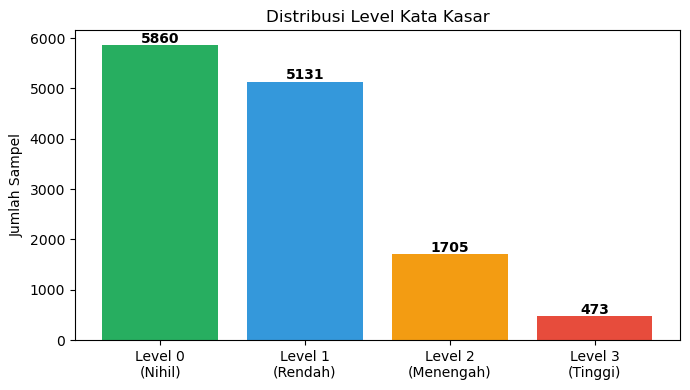

In [7]:
def map_to_level(row):
    """Map Kaggle hate speech labels to 0-3 profanity level scale."""
    if row['HS'] == 0 and row['Abusive'] == 0:
        return 0  # Nihil
    elif row['HS_Strong'] == 1:
        return 3  # Tinggi
    elif row['HS_Moderate'] == 1:
        return 2  # Menengah
    else:
        return 1  # Rendah (HS_Weak or Abusive)

df['Level Kata Kasar'] = df.apply(map_to_level, axis=1)

print('Level distribution:')
level_counts = df['Level Kata Kasar'].value_counts().sort_index()
for level, count in level_counts.items():
    label = {0: 'Nihil', 1: 'Rendah', 2: 'Menengah', 3: 'Tinggi'}[level]
    print(f'  Level {level} ({label}): {count:,} ({count/len(df)*100:.1f}%)')

# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#27ae60', '#3498db', '#f39c12', '#e74c3c']
labels = ['Level 0\n(Nihil)', 'Level 1\n(Rendah)', 'Level 2\n(Menengah)', 'Level 3\n(Tinggi)']
ax.bar(labels, level_counts.values, color=colors)
ax.set_title('Distribusi Level Kata Kasar')
ax.set_ylabel('Jumlah Sampel')
for i, v in enumerate(level_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4: Penanganan Class Imbalance

Dataset menunjukkan ketidakseimbangan kelas yang signifikan (Level 0: ~44%, Level 3: ~3.6%).  
Sesuai proposal (Bagian 3.2), penelitian ini menggunakan **random oversampling** — duplikasi  
acak sampel kelas minoritas — sebagai pendekatan yang lebih sederhana dibanding SMOTE dan  
terbukti kompetitif pada dataset multi-kelas berukuran kecil–menengah (Zhang dkk., 2024).

> Oversampling **hanya diterapkan pada data latih** (setelah train/test split) untuk
> menghindari data leakage ke test set.


In [8]:
# ── Random Oversampling (training set only, applied in Section 7) ────────────
# Preview of class imbalance before any split/oversampling
from sklearn.utils import resample

print('Class distribution in full dataset:')
level_counts = df['Level Kata Kasar'].value_counts().sort_index()
for lvl, cnt in level_counts.items():
    bar = '█' * int(cnt / 100)
    print(f'  Level {lvl}: {cnt:5,}  {bar}')

print()
print('Imbalance ratio (majority / minority):', round(level_counts.max() / level_counts.min(), 1))
print('\n→ Random oversampling will be applied to the training split in Section 7.')


def random_oversample(X_ml_ser, X_bert_ser, y_ser, random_state=42):
    """Oversample minority classes to match the majority class count."""
    max_count = y_ser.value_counts().max()
    parts_ml, parts_bert, parts_y = [], [], []

    for label in sorted(y_ser.unique()):
        mask = (y_ser == label).values
        Xm = X_ml_ser[mask].reset_index(drop=True)
        Xb = X_bert_ser[mask].reset_index(drop=True)
        ys = y_ser[mask].reset_index(drop=True)
        n  = len(ys)

        if n < max_count:
            idx = resample(range(n), n_samples=max_count,
                           random_state=random_state, replace=True)
            Xm, Xb, ys = Xm.iloc[idx], Xb.iloc[idx], ys.iloc[idx]

        parts_ml.append(Xm)
        parts_bert.append(Xb)
        parts_y.append(ys)

    return (
        pd.concat(parts_ml).reset_index(drop=True),
        pd.concat(parts_bert).reset_index(drop=True),
        pd.concat(parts_y).reset_index(drop=True),
    )


Class distribution in full dataset:
  Level 0: 5,860  ██████████████████████████████████████████████████████████
  Level 1: 5,131  ███████████████████████████████████████████████████
  Level 2: 1,705  █████████████████
  Level 3:   473  ████

Imbalance ratio (majority / minority): 12.4

→ Random oversampling will be applied to the training split in Section 7.


## Section 5: Preprocessing Pipeline

7-step preprocessing pipeline sesuai proposal:
1. **Deteksi Penyamaran** – RegEx `[0-9@!$.|]`
2. **Lowercasing** – `.lower()`
3. **Penghapusan spasi berlebih** – gabungkan karakter yang dipisah spasi
4. **Pembersihan tanda baca** – hapus `.`, `-`, `_`, `'`, `;`, `"`
5. **Substitusi leet speak** – konversi angka/simbol ke huruf
6. **Tokenisasi** – `word_tokenize`
7. **Stemming** – PySastrawi

In [9]:
# ── Initialize PySastrawi ──────────────────────────────────────
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopword_list = set(stopword_factory.get_stop_words())

# ── Leet speak substitution map ───────────────────────────────
LEET_MAP = {
    '0': 'o', '1': 'i', '2': 'z', '3': 'e', '4': 'a',
    '5': 's', '6': 'g', '7': 't', '8': 'b', '9': 'g',
    '@': 'a', '!': 'i', '$': 's',
}

# ── Preprocessing functions ────────────────────────────────────

def detect_disguise(text: str) -> int:
    """Step 1: Flag text that contains leet-speak characters."""
    return 1 if re.search(r'[0-9@!$.|]', str(text)) else 0


def lowercase(text: str) -> str:
    """Step 2: Lowercase."""
    return str(text).lower()


def remove_excessive_spaces(text: str) -> str:
    """
    Step 3: Collapse spaced-out characters.
    'a n j i n g' -> 'anjing'
    """
    def join_match(m):
        return m.group(0).replace(' ', '')
    return re.sub(r'(?<!\w)(\w\s){2,}\w(?!\w)', join_match, text)


def clean_punctuation(text: str) -> str:
    """
    Step 4: Remove punctuation that rarely substitutes letters.
    Keeps *, !, @ (common in disguised profanity).
    """
    return re.sub(r'(?<=[a-z])[.\-_\';"\u201c\u201d](?=[a-z])', '', text)


def substitute_leet(text: str) -> str:
    """Step 5: Convert leet-speak characters back to letters."""
    return ''.join(LEET_MAP.get(c, c) for c in text)


def normalize_slang(tokens: list, slang_dict: dict) -> list:
    """Normalize slang words using kamusalay dictionary."""
    normalized = []
    for token in tokens:
        formal = slang_dict.get(token, token)
        # slang may map to multi-word phrase; split and add all
        normalized.extend(formal.split())
    return normalized


def tokenize(text: str) -> list:
    """Step 6: Tokenize using NLTK word_tokenize."""
    return word_tokenize(text)


def stem_tokens(tokens: list) -> list:
    """Step 7: Stem with PySastrawi."""
    return [stemmer.stem(t) for t in tokens]


def preprocess(text: str, for_bert: bool = False) -> str:
    """
    Full preprocessing pipeline.
    for_bert=True  → skip tokenization & stemming (BERT has its own tokenizer).
    for_bert=False → return stemmed, space-joined token string for TF-IDF.
    """
    text = lowercase(text)                  # step 2
    text = remove_excessive_spaces(text)    # step 3
    text = clean_punctuation(text)          # step 4
    text = substitute_leet(text)            # step 5
    # Remove remaining non-alphanumeric characters (except spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if for_bert:
        return text  # return as clean string; BERT uses AutoTokenizer

    tokens = tokenize(text)                         # step 6
    tokens = [t for t in tokens if t.isalpha()]     # drop punctuation tokens
    tokens = normalize_slang(tokens, slang_dict)    # slang normalization
    tokens = stem_tokens(tokens)                    # step 7

    return ' '.join(tokens)


# Quick sanity check
test_cases = [
    "a n j i n g kamu!",
    "d4s4r b4ngs4t",
    "Hari ini cuaca cerah sekali.",
    "dasar b@ngs@t lu!",
]
print('Preprocessing sanity check:')
for t in test_cases:
    print(f'  Original : {t}')
    print(f'  For ML   : {preprocess(t, for_bert=False)}')
    print(f'  For BERT : {preprocess(t, for_bert=True)}')
    print()

Preprocessing sanity check:
  Original : a n j i n g kamu!
  For ML   : anjing kamu
  For BERT : anjing kamui

  Original : d4s4r b4ngs4t
  For ML   : dasar bangsat
  For BERT : dasar bangsat

  Original : Hari ini cuaca cerah sekali.
  For ML   : hari ini cuaca cerah sekali
  For BERT : hari ini cuaca cerah sekali

  Original : dasar b@ngs@t lu!
  For ML   : dasar bangsat lui
  For BERT : dasar bangsat lui



In [10]:
if not FORCE_RETRAIN and os.path.exists(OUTPUT_PATH):
    print(f'Loading preprocessed dataset from {OUTPUT_PATH} (set FORCE_RETRAIN=True to recompute)')
    df_saved = pd.read_csv(OUTPUT_PATH, encoding='utf-8')
    df['Kalimat Asli']         = df_saved['Kalimat Asli'].values
    df['Kalimat Dinormalisasi']= df_saved['Kalimat Dinormalisasi'].values
    df['Disamarkan']           = df_saved['Disamarkan'].values
    # BERT column isn't in the saved CSV — regenerate it cheaply (no stemming)
    tqdm.pandas(desc='Preprocessing for BERT')
    df['Kalimat Bert'] = df['Kalimat Asli'].progress_apply(
        lambda x: preprocess(x, for_bert=True)
    )
else:
    print('Running preprocessing (this may take a few minutes)...')
    df['Kalimat Asli'] = df['Tweet'].astype(str)
    df['Disamarkan']   = df['Kalimat Asli'].apply(detect_disguise)
    tqdm.pandas(desc='Preprocessing for ML')
    df['Kalimat Dinormalisasi'] = df['Kalimat Asli'].progress_apply(
        lambda x: preprocess(x, for_bert=False)
    )
    tqdm.pandas(desc='Preprocessing for BERT')
    df['Kalimat Bert'] = df['Kalimat Asli'].progress_apply(
        lambda x: preprocess(x, for_bert=True)
    )

print('\nPreprocessing ready!')
df[['Kalimat Asli', 'Kalimat Dinormalisasi', 'Level Kata Kasar', 'Disamarkan']].head(5)


Loading preprocessed dataset from dataset_processed.csv (set FORCE_RETRAIN=True to recompute)


Preprocessing for BERT: 100%|██████████| 13169/13169 [00:00<00:00, 43254.71it/s]


Preprocessing ready!


,Kalimat Asli,Kalimat Dinormalisasi,Level Kata Kasar,Disamarkan
0,- disaat semua cowok berusaha melacak perhatia...,di saat semua cowok usaha lacak perhati gue ka...,1,1
1,RT USER: USER siapa yang telat ngasih tau elu?...,rt guna guna siapa yang telat beri tau kamu ed...,1,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",ai kadang aku pikir kenapa aku tetap percaya p...,0,1
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,guna guna aku itu aku dan ku tau mata sipit ta...,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,guna guna kaum cebong kafir sudah lihat dongok...,2,0


In [11]:
# Save processed dataset (format sesuai proposal)
df_out = df[['Kalimat Asli', 'Kalimat Dinormalisasi', 'Level Kata Kasar', 'Disamarkan']].copy()
df_out.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f'Saved processed dataset → {OUTPUT_PATH}')
print(f'Shape: {df_out.shape}')
print(f'Disguised sentences: {df["Disamarkan"].sum():,} ({df["Disamarkan"].mean()*100:.1f}%)')

Saved processed dataset → dataset_processed.csv
Shape: (13169, 4)
Disguised sentences: 8,831 (67.1%)


## Section 6: Lexicon Kata Kasar

Lexicon dibangun berdasarkan **`paper/indonesian_swear_lexicon.xlsx`** — daftar kata kasar yang  
telah divalidasi secara manual dan hanya mencakup kata-kata yang **selalu** bersifat kasar  
(context-independent). Total: **22 entri** di tiga tingkat kekasaran.

Kata-kata dengan makna ganda (`anjing`, `babi`, `gila`, `edan`, `kampung`) **tidak** dimasukkan  
ke dalam lexicon — ditangani secara kontekstual oleh IndoBERT (lihat Sheet 2 pada xlsx).  
Fuzzy matching via RapidFuzz digunakan untuk mendeteksi varian leet-speak yang lolos preprocessing.

| Level | Label | Contoh kata |
|-------|-------|-------------|
| 1 | Mild | goblok, tolol, bego, sinting |
| 2 | Moderate | bangsat, bajingan, keparat, asu |
| 3 | Severe | jancok, kontol, memek, lonte |


In [12]:
# ── Load profanity lexicon from paper/indonesian_swear_lexicon.xlsx ──────────
# Fallback: hardcoded validated entries (same data, openpyxl not required)
try:
    import zipfile, re as _re
    _SEVERITY_MAP = {'1': 1, '2': 2, '3': 3}
    def _parse_xlsx_lexicon(path):
        with zipfile.ZipFile(path) as z:
            with z.open('xl/worksheets/sheet1.xml') as f:
                content = f.read().decode('utf-8')
        rows = {}
        for m in _re.finditer(r'<row r="(\d+)"[^>]*>(.*?)</row>', content, _re.DOTALL):
            row_num = int(m.group(1))
            if row_num < 3:
                continue
            cells_text = _re.findall(r'<is><t[^>]*>(.*?)</t></is>', m.group(2))
            if len(cells_text) >= 2:
                word = cells_text[0].strip().lower()
                severity_raw = cells_text[1].strip()
                level = int(severity_raw[0]) if severity_raw and severity_raw[0].isdigit() else None
                if word and level:
                    rows[word] = level
        return rows
    LEXICON = _parse_xlsx_lexicon('paper/indonesian_swear_lexicon.xlsx')
    print(f'Lexicon loaded from xlsx: {len(LEXICON)} entries')
except Exception as _e:
    print(f'xlsx load failed ({_e}), using hardcoded lexicon')
    LEXICON = {
        # Level 1 – Mild (context-independent insults, no dual meaning)
        'goblok': 1, 'tolol': 1, 'bego': 1, 'dungu': 1, 'idiot': 1, 'bodoh': 1,
        'kampungan': 1, 'kurang ajar': 1, 'sinting': 1,

        # Level 2 – Moderate (strong insults, comparable to regional expletives)
        'bangsat': 2, 'bajingan': 2, 'brengsek': 2, 'keparat': 2,
        'sialan': 2, 'kampret': 2, 'celaka': 2, 'asu': 2,

        # Level 3 – Severe (explicit sexual / misogynistic content)
        'jancok': 3, 'jancuk': 3, 'kontol': 3, 'memek': 3,
        'lonte': 3, 'pelacur': 3,
    }
    print(f'Lexicon loaded (hardcoded): {len(LEXICON)} entries')

# Words with innocent dual meanings — excluded from lexicon, handled by IndoBERT
# Source: paper/indonesian_swear_lexicon.xlsx, Sheet 2
AMBIGUOUS_WORDS = {'anjing', 'babi', 'gila', 'edan', 'kampung'}


def lexicon_match(text: str, threshold: int = 85) -> int:
    """
    Match preprocessed text against LEXICON using exact + fuzzy matching.
    Returns the highest profanity level found (0 if none).
    Multi-word entries (e.g. 'kurang ajar') are checked as bigrams.
    """
    if not text or not isinstance(text, str):
        return 0

    tokens = text.split()
    max_level = 0

    # Build candidate list: individual tokens + consecutive bigrams
    candidates = list(tokens)
    candidates += [tokens[i] + ' ' + tokens[i+1] for i in range(len(tokens) - 1)]

    for candidate in candidates:
        if candidate in AMBIGUOUS_WORDS:
            continue

        # Exact match
        if candidate in LEXICON:
            max_level = max(max_level, LEXICON[candidate])
            continue

        # Fuzzy match (catches disguised/modified words)
        result = process.extractOne(candidate, LEXICON.keys(), scorer=fuzz.ratio)
        if result and result[1] >= threshold:
            max_level = max(max_level, LEXICON[result[0]])

    return max_level


# Sanity check
test_words = [
    ('tolol banget sih', 'exact match level 1'),
    ('dasar bangsat kamu', 'exact match level 2'),
    ('d4s4r j4nc0k', 'leet speak level 3 — after preprocessing'),
    ('hari ini cerah', 'no profanity'),
    ('anjing saya sakit', 'ambiguous — should be 0 from lexicon'),
    ('kurang ajar kamu', 'multi-word level 1'),
]
print('\nLexicon match test:')
for text, desc in test_words:
    pre = preprocess(text, for_bert=False)
    level = lexicon_match(pre)
    print(f'  [{desc}]')
    print(f'    Input: "{text}" -> preprocessed: "{pre}" -> Level: {level}')

print(f'\nTotal lexicon entries: {len(LEXICON)}')
print(f'Level distribution: ' + str({k: sum(1 for v in LEXICON.values() if v == k) for k in [1,2,3]}))


Lexicon loaded from xlsx: 22 entries

Lexicon match test:
  [exact match level 1]
    Input: "tolol banget sih" -> preprocessed: "tolol banget sih" -> Level: 1
  [exact match level 2]
    Input: "dasar bangsat kamu" -> preprocessed: "dasar bangsat kamu" -> Level: 2
  [leet speak level 3 — after preprocessing]
    Input: "d4s4r j4nc0k" -> preprocessed: "dasar jancuk" -> Level: 3
  [no profanity]
    Input: "hari ini cerah" -> preprocessed: "hari ini cerah" -> Level: 0
  [ambiguous — should be 0 from lexicon]
    Input: "anjing saya sakit" -> preprocessed: "anjing saya sakit" -> Level: 0
  [multi-word level 1]
    Input: "kurang ajar kamu" -> preprocessed: "kurang ajar kamu" -> Level: 1

Total lexicon entries: 22
Level distribution: {1: 8, 2: 8, 3: 6}


## Section 7: Feature Extraction & Train/Test Split

In [13]:
# Drop rows with empty preprocessed text
df_clean = df.dropna(subset=['Kalimat Dinormalisasi', 'Kalimat Bert']).copy()
df_clean = df_clean[
    (df_clean['Kalimat Dinormalisasi'].str.strip() != '') &
    (df_clean['Kalimat Bert'].str.strip() != '')
].reset_index(drop=True)

# Optional: limit dataset size for faster testing
if MAX_SAMPLES is not None:
    df_clean = df_clean.sample(n=min(MAX_SAMPLES, len(df_clean)),
                               random_state=RANDOM_STATE).reset_index(drop=True)

X_ml   = df_clean['Kalimat Dinormalisasi']  # for LR + NB
X_bert = df_clean['Kalimat Bert']           # for IndoBERT
y      = df_clean['Level Kata Kasar']

print(f'Total samples: {len(df_clean):,}')
print(f'Label distribution:\n{y.value_counts().sort_index()}')

# ── Train / Test Split ────────────────────────────────────────
# Split indices once, reuse for all three models
(X_train_ml,  X_test_ml,
 X_train_bert, X_test_bert,
 y_train,      y_test) = train_test_split(
    X_ml, X_bert, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'\nTrain: {len(y_train):,} | Test: {len(y_test):,}')

# ── Apply random oversampling to training set ───────────────────────────────
X_train_ml, X_train_bert, y_train = random_oversample(
    X_train_ml, X_train_bert, y_train, random_state=RANDOM_STATE
)
print(f'Train after oversampling: {len(y_train):,} | Distribution: {y_train.value_counts().sort_index().to_dict()}')


# ── TF-IDF Vectorizers ────────────────────────────────────────
# Logistic Regression: character n-gram (2-5), as per proposal
tfidf_lr = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True,
)

# Naive Bayes: word n-gram (1-2)
tfidf_nb = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True,
)

X_train_lr = tfidf_lr.fit_transform(X_train_ml)
X_test_lr  = tfidf_lr.transform(X_test_ml)

X_train_nb = tfidf_nb.fit_transform(X_train_ml)
X_test_nb  = tfidf_nb.transform(X_test_ml)

print(f'\nTF-IDF (LR) shape: {X_train_lr.shape}')
print(f'TF-IDF (NB) shape: {X_train_nb.shape}')

Total samples: 13,169
Label distribution:
Level Kata Kasar
0    5860
1    5131
2    1705
3     473
Name: count, dtype: int64

Train: 10,535 | Test: 2,634
Train after oversampling: 18,752 | Distribution: {0: 4688, 1: 4688, 2: 4688, 3: 4688}

TF-IDF (LR) shape: (18752, 42826)
TF-IDF (NB) shape: (18752, 46457)


## Section 8: Model 1 – Logistic Regression

Logistic Regression dengan representasi fitur TF-IDF character n-gram.

In [14]:
LR_PATH = 'saved_models/lr_model.pkl'

if not FORCE_RETRAIN and os.path.exists(LR_PATH):
    import pickle
    with open(LR_PATH, 'rb') as f: lr_model = pickle.load(f)
    with open('saved_models/lr_tfidf.pkl', 'rb') as f: tfidf_lr = pickle.load(f)
    X_test_lr  = tfidf_lr.transform(X_test_ml)
    X_train_lr = tfidf_lr.transform(X_train_ml)  # needed if SVM runs next
    print('Logistic Regression loaded from disk.')
else:
    print('Training Logistic Regression...')
    lr_model = LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        random_state=RANDOM_STATE, class_weight='balanced',
    )
    lr_model.fit(X_train_lr, y_train)

y_pred_lr = lr_model.predict(X_test_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
print(f'\nLogistic Regression – F1-Score (macro): {f1_lr:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr,
      target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']))


Logistic Regression loaded from disk.

Logistic Regression – F1-Score (macro): 0.6942

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.85      0.70      0.77      1172
     Level 1       0.69      0.81      0.75      1026
     Level 2       0.52      0.55      0.54       341
     Level 3       0.69      0.77      0.73        95

    accuracy                           0.73      2634
   macro avg       0.69      0.71      0.69      2634
weighted avg       0.74      0.73      0.73      2634



## Section 9: Model 2 – Naive Bayes

Complement Naive Bayes (lebih baik dari Multinomial NB untuk dataset imbalanced).

In [15]:
NB_PATH = 'saved_models/nb_model.pkl'

if not FORCE_RETRAIN and os.path.exists(NB_PATH):
    import pickle
    with open(NB_PATH, 'rb') as f: nb_model = pickle.load(f)
    with open('saved_models/nb_tfidf.pkl', 'rb') as f: tfidf_nb = pickle.load(f)
    X_test_nb = tfidf_nb.transform(X_test_ml)
    print('Naive Bayes loaded from disk.')
else:
    print('Training Naive Bayes...')
    nb_model = ComplementNB(alpha=0.1)
    nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='macro')
print(f'\nNaive Bayes – F1-Score (macro): {f1_nb:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb,
      target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']))


Naive Bayes loaded from disk.

Naive Bayes – F1-Score (macro): 0.6040

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.83      0.80      0.81      1172
     Level 1       0.68      0.87      0.76      1026
     Level 2       0.69      0.29      0.41       341
     Level 3       0.74      0.31      0.43        95

    accuracy                           0.74      2634
   macro avg       0.73      0.57      0.60      2634
weighted avg       0.75      0.74      0.73      2634



## Section 10: Model 3 – Support Vector Machine (SVM)

LinearSVC dengan representasi fitur TF-IDF character n-gram (sama seperti Logistic Regression).  
`LinearSVC` dipilih karena efisien pada ruang fitur berdimensi tinggi dan terbukti kuat untuk  
klasifikasi teks. `class_weight='balanced'` digunakan untuk menangani ketidakseimbangan kelas.


In [16]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

SVM_PATH = 'saved_models/svm_model.pkl'

if not FORCE_RETRAIN and os.path.exists(SVM_PATH):
    import pickle
    with open(SVM_PATH, 'rb') as f: svm_model = pickle.load(f)
    print('SVM loaded from disk.')
else:
    print('Training SVM (LinearSVC)...')
    svm_base  = LinearSVC(C=1.0, max_iter=2000,
                          class_weight='balanced', random_state=RANDOM_STATE)
    svm_model = CalibratedClassifierCV(svm_base, cv=5)
    svm_model.fit(X_train_lr, y_train)  # shares LR TF-IDF

y_pred_svm = svm_model.predict(X_test_lr)
f1_svm = f1_score(y_test, y_pred_svm, average='macro')
print(f'\nSVM (LinearSVC) – F1-Score (macro): {f1_svm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm,
      target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']))


Training SVM (LinearSVC)...

SVM (LinearSVC) – F1-Score (macro): 0.7549

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.83      0.89      0.86      1172
     Level 1       0.82      0.76      0.79      1026
     Level 2       0.59      0.57      0.58       341
     Level 3       0.77      0.83      0.80        95

    accuracy                           0.79      2634
   macro avg       0.75      0.76      0.75      2634
weighted avg       0.79      0.79      0.79      2634



## Section 11: Model 4 – IndoBERTweet

IndoBERTweet (`indolem/indobertweet-base`) di-fine-tune untuk klasifikasi 4 kelas.  
Model ini dipilih karena dataset dominan bersumber dari media sosial (Twitter/X) —  
IndoBERTweet dilatih khusus menggunakan **26 juta tweet berbahasa Indonesia** sehingga  
lebih menguasai kosakata dan gaya penulisan media sosial dibanding IndoBERT umum  
(Koto dkk., 2021).

> **Catatan:** Fine-tuning di CPU membutuhkan waktu lebih lama. Kurangi `MAX_SAMPLES`
> atau `EPOCHS` untuk mempercepat pengujian.


In [17]:
class ProfanityDataset(Dataset):
    """PyTorch Dataset for IndoBERT fine-tuning."""

    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [18]:
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

BERT_SAVE_PATH = 'saved_models/indobert_finetuned'
# Load fine-tuned weights if available; otherwise load the base pre-trained model
_load_path = BERT_SAVE_PATH if (not FORCE_RETRAIN and os.path.exists(BERT_SAVE_PATH)) else INDOBERT_MODEL
print(f'Loading BERT from: {_load_path}')

bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_SAVE_PATH if os.path.exists(BERT_SAVE_PATH) else INDOBERT_MODEL
)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    _load_path,
    num_labels=4,
    ignore_mismatched_sizes=True,
)
bert_model = bert_model.to(device)
hf_logging.set_verbosity_warning()

total_params  = sum(p.numel() for p in bert_model.parameters())
trainable     = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
already_tuned = os.path.exists(BERT_SAVE_PATH) and not FORCE_RETRAIN
print(f'Total params: {total_params:,} | Trainable: {trainable:,}')
print(f'Status: {"fine-tuned weights loaded" if already_tuned else "base model — fine-tuning needed"}')


Loading BERT from: saved_models/indobert_finetuned


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8152.55it/s]


Total params: 124,444,420 | Trainable: 124,444,420
Status: fine-tuned weights loaded


In [19]:
train_dataset = ProfanityDataset(
    X_train_bert.reset_index(drop=True),
    y_train.reset_index(drop=True),
    bert_tokenizer
)
test_dataset = ProfanityDataset(
    X_test_bert.reset_index(drop=True),
    y_test.reset_index(drop=True),
    bert_tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 1172 | Test batches: 165


In [21]:
if not FORCE_RETRAIN or os.path.exists(BERT_SAVE_PATH):
    # ── Optimizer & Scheduler ──────────────────────────────────────
    optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, total_steps // 10),
        num_training_steps=total_steps,
    )
    
    
    def train_one_epoch(model, loader, optimizer, scheduler, device):
        model.train()
        total_loss = 0.0
        for batch in tqdm(loader, desc='  Training', leave=False):
            optimizer.zero_grad()
            out = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device),
            )
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += out.loss.item()
        return total_loss / len(loader)
    
    
    def evaluate_bert(model, loader, device):
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc='  Evaluating', leave=False):
                out = model(
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                )
                preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
                trues.extend(batch['labels'].numpy())
        return np.array(preds), np.array(trues)
    
    
    # ── Training Loop ──────────────────────────────────────────────
    print(f'Fine-tuning IndoBERT for {EPOCHS} epoch(s) on {device}...\n')
    history = []
    
    for epoch in range(1, EPOCHS + 1):
        avg_loss = train_one_epoch(bert_model, train_loader, optimizer, scheduler, device)
        y_pred_ep, y_true_ep = evaluate_bert(bert_model, test_loader, device)
        ep_f1 = f1_score(y_true_ep, y_pred_ep, average='macro')
        history.append({'epoch': epoch, 'loss': avg_loss, 'f1': ep_f1})
        print(f'Epoch {epoch}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  F1 (macro): {ep_f1:.4f}')
    
    # Final evaluation
    y_pred_bert, y_true_bert = evaluate_bert(bert_model, test_loader, device)
    f1_bert = f1_score(y_true_bert, y_pred_bert, average='macro')
    
    print(f'\nIndoBERT – F1-Score (macro): {f1_bert:.4f}')
    print('\nClassification Report:')
    print(classification_report(
        y_true_bert, y_pred_bert,
        target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']
    ))
else:
    print('IndoBERTweet fine-tuned weights already loaded — skipping training.')
    print('Set FORCE_RETRAIN=True in config to retrain.')

# Evaluate on test set regardless (weights are already in bert_model)
y_pred_bert, y_true_bert = evaluate_bert(bert_model, test_loader, device)
f1_bert = f1_score(y_true_bert, y_pred_bert, average='macro')
print(f'\nIndoBERTweet – F1-Score (macro): {f1_bert:.4f}')
print('\nClassification Report:')
print(classification_report(
    y_true_bert, y_pred_bert,
    target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']
))


Fine-tuning IndoBERT for 3 epoch(s) on cuda...



Epoch 1/3  |  Loss: 0.1583  |  F1 (macro): 0.7793


Epoch 2/3  |  Loss: 0.0654  |  F1 (macro): 0.7768


Epoch 3/3  |  Loss: 0.0163  |  F1 (macro): 0.7940



IndoBERT – F1-Score (macro): 0.7940

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.89      0.91      0.90      1172
     Level 1       0.83      0.82      0.82      1026
     Level 2       0.66      0.60      0.63       341
     Level 3       0.80      0.85      0.83        95

    accuracy                           0.83      2634
   macro avg       0.79      0.80      0.79      2634
weighted avg       0.83      0.83      0.83      2634




IndoBERTweet – F1-Score (macro): 0.7940

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.89      0.91      0.90      1172
     Level 1       0.83      0.82      0.82      1026
     Level 2       0.66      0.60      0.63       341
     Level 3       0.80      0.85      0.83        95

    accuracy                           0.83      2634
   macro avg       0.79      0.80      0.79      2634
weighted avg       0.83      0.83      0.83      2634



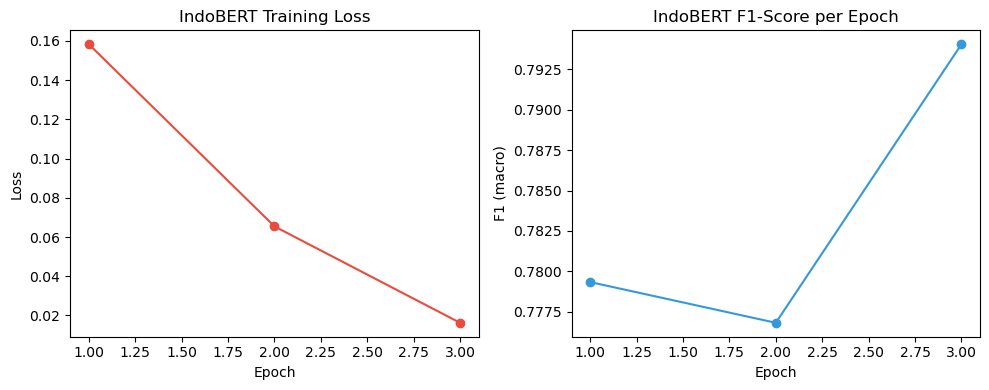

In [22]:
# Plot training history
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(hist_df['epoch'], hist_df['loss'], marker='o', color='#e74c3c')
ax1.set_title('IndoBERT Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax2.plot(hist_df['epoch'], hist_df['f1'], marker='o', color='#3498db')
ax2.set_title('IndoBERT F1-Score per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12: Evaluasi & Perbandingan Model

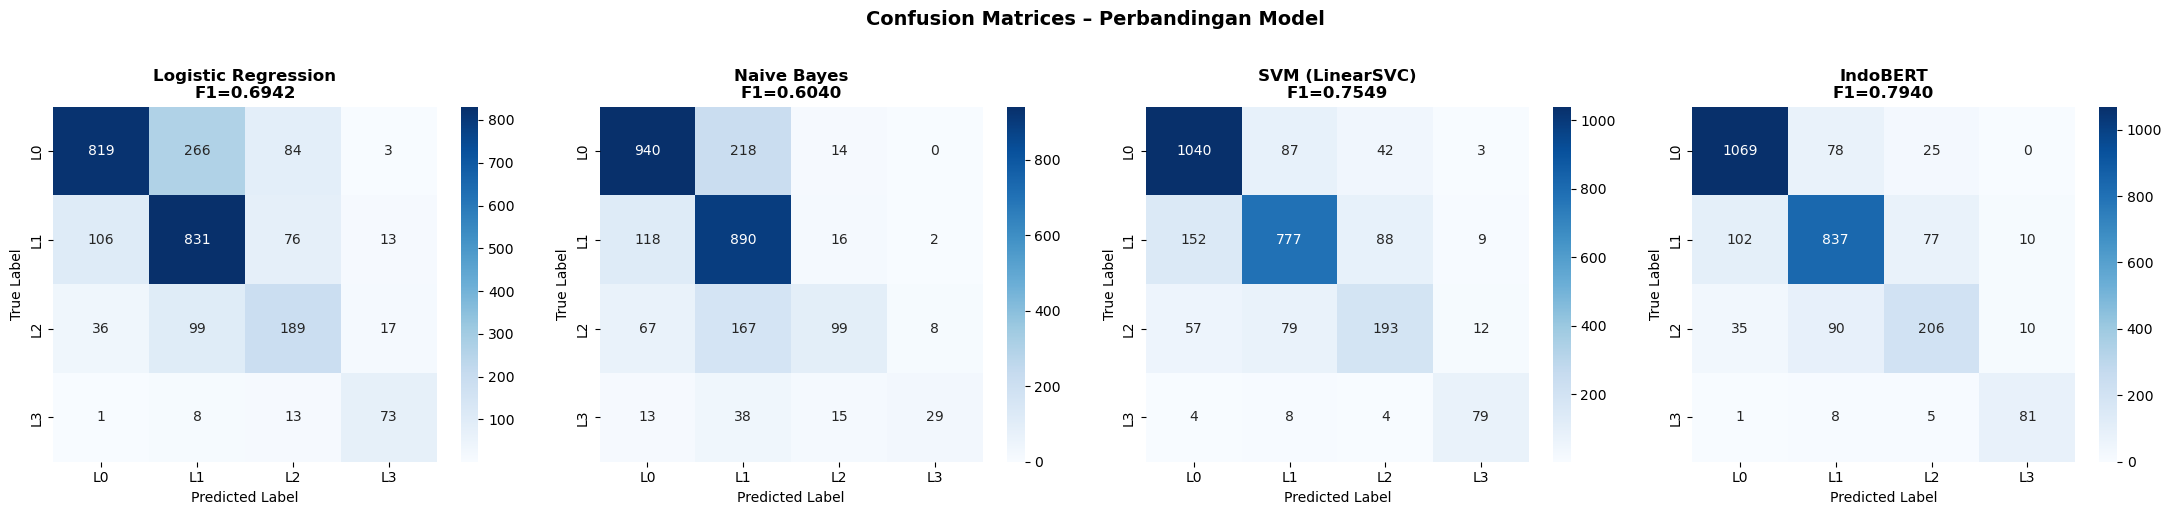

In [23]:
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['L0', 'L1', 'L2', 'L3'],
        yticklabels=['L0', 'L1', 'L2', 'L3'],
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')


fig, axes = plt.subplots(1, 4, figsize=(22, 5))
plot_cm(y_test,      y_pred_lr,   f'Logistic Regression\nF1={f1_lr:.4f}',  axes[0])
plot_cm(y_test,      y_pred_nb,   f'Naive Bayes\nF1={f1_nb:.4f}',          axes[1])
plot_cm(y_test,      y_pred_svm,  f'SVM (LinearSVC)\nF1={f1_svm:.4f}',     axes[2])
plot_cm(y_true_bert, y_pred_bert, f'IndoBERT\nF1={f1_bert:.4f}',           axes[3])
plt.suptitle('Confusion Matrices – Perbandingan Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


=== Model Comparison ===

                     Precision (macro)  Recall (macro)  F1 (macro)
Logistic Regression             0.6881          0.7079      0.6942
Naive Bayes                     0.7337          0.5663      0.6040
SVM (LinearSVC)                 0.7511          0.7606      0.7549
IndoBERT                        0.7930          0.7962      0.7940


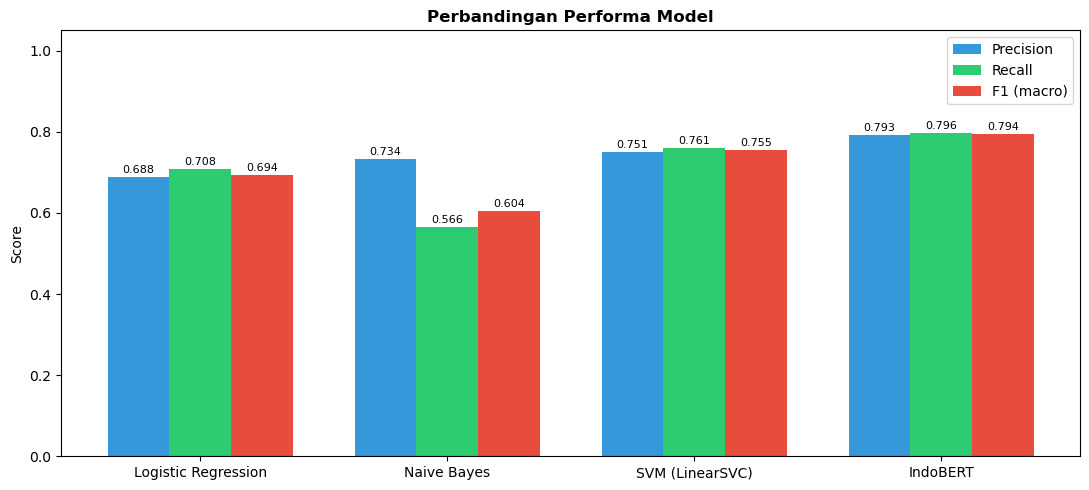

In [24]:
# ── Summary Table ─────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

def get_metrics(y_true, y_pred):
    return {
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test,      y_pred_lr),
    'Naive Bayes':         get_metrics(y_test,      y_pred_nb),
    'SVM (LinearSVC)':     get_metrics(y_test,      y_pred_svm),
    'IndoBERT':            get_metrics(y_true_bert, y_pred_bert),
}).T.round(4)

print('=== Model Comparison ===\n')
print(results.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results))
w = 0.25
bars1 = ax.bar(x - w, results['Precision (macro)'], w, label='Precision', color='#3498db')
bars2 = ax.bar(x,     results['Recall (macro)'],    w, label='Recall',    color='#2ecc71')
bars3 = ax.bar(x + w, results['F1 (macro)'],        w, label='F1 (macro)',color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(results.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model', fontweight='bold')
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 13: Inference Demo

Fungsi prediksi yang menggabungkan lexicon matching + IndoBERT classification.

In [25]:
LEVEL_LABELS = {
    0: 'Nihil (Tidak ada kata kasar)',
    1: 'Rendah (Mild profanity)',
    2: 'Menengah (Moderate profanity)',
    3: 'Tinggi (Severe/Explicit profanity)',
}


def predict(text: str, verbose: bool = True) -> dict:
    """
    Predict the profanity level of an Indonesian text.

    Pipeline:
      1. Detect if text contains disguised characters.
      2. Preprocess.
      3. Lexicon match (with RapidFuzz fuzzy matching).
      4. Classical models: LR, NB, SVM (TF-IDF char n-gram).
      5. IndoBERTweet contextual classification.
    """
    disguised = detect_disguise(text)
    prep_ml   = preprocess(text, for_bert=False)
    prep_bert = preprocess(text, for_bert=True)
    lex_level = lexicon_match(prep_ml)

    # Classical model predictions
    vec_lr  = tfidf_lr.transform([prep_ml])
    lr_level  = int(lr_model.predict(vec_lr)[0])
    nb_level  = int(nb_model.predict(tfidf_nb.transform([prep_ml]))[0])
    svm_level = int(svm_model.predict(vec_lr)[0])  # shares LR TF-IDF

    # IndoBERT prediction
    bert_model.eval()
    enc = bert_tokenizer(
        prep_bert,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    with torch.no_grad():
        logits = bert_model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device),
        ).logits

    probs      = torch.softmax(logits, dim=1)[0].cpu().numpy()
    bert_level = int(np.argmax(probs))
    confidence = float(probs[bert_level])

    result = {
        'input':         text,
        'disguised':     bool(disguised),
        'preprocessed':  prep_ml,
        'lexicon_level': lex_level,
        'lr_level':      lr_level,
        'nb_level':      nb_level,
        'svm_level':     svm_level,
        'bert_level':    bert_level,
        'confidence':    confidence,
        'probabilities': {f'L{i}': round(float(p), 4) for i, p in enumerate(probs)},
    }

    if verbose:
        print(f'Input       : {text}')
        print(f'Disguised   : {result["disguised"]}')
        print(f'Preprocessed: {prep_ml}')
        print(f'Lexicon     : Level {lex_level} – {LEVEL_LABELS[lex_level]}')
        print(f'LR          : Level {lr_level}  – {LEVEL_LABELS[lr_level]}')
        print(f'NB          : Level {nb_level}  – {LEVEL_LABELS[nb_level]}')
        print(f'SVM         : Level {svm_level}  – {LEVEL_LABELS[svm_level]}')
        print(f'IndoBERT    : Level {bert_level}  – {LEVEL_LABELS[bert_level]}  (confidence: {confidence:.1%})')
        print(f'Probs       : {result["probabilities"]}')
        print()

    return result


In [26]:
print('=' * 60)
print('INFERENCE DEMO')
print('=' * 60)

test_sentences = [
    # Level 0 – no profanity
    'Hari ini cuaca sangat cerah dan menyenangkan.',
    'Saya pergi ke sekolah bersama teman-teman.',

    # Level 0 – ambiguous words in neutral context (IndoBERT should catch this)
    'Anjing saya sakit dan harus ke dokter hewan.',
    'Gila, pemandangannya indah sekali!',

    # Level 1 – mild profanity
    'Duh, tolol banget sih kamu ini.',
    'Goblok amat, masa gitu aja salah!',

    # Level 2 – moderate profanity
    'Dasar bajingan, berani-beraninya kamu!',
    'Sialan banget kelakuan kamu tuh.',

    # Level 3 – severe, with disguise
    'd4s4r j4nc0k kamu!',
    'a n j i n g, kontol banget sih!',
]

for sentence in test_sentences:
    print('-' * 60)
    predict(sentence, verbose=True)

INFERENCE DEMO
------------------------------------------------------------
Input       : Hari ini cuaca sangat cerah dan menyenangkan.
Disguised   : True
Preprocessed: hari ini cuaca sangat cerah dan senang
Lexicon     : Level 0 – Nihil (Tidak ada kata kasar)
LR          : Level 0  – Nihil (Tidak ada kata kasar)
NB          : Level 0  – Nihil (Tidak ada kata kasar)
SVM         : Level 0  – Nihil (Tidak ada kata kasar)
IndoBERT    : Level 0  – Nihil (Tidak ada kata kasar)  (confidence: 100.0%)
Probs       : {'L0': 0.9999, 'L1': 0.0, 'L2': 0.0, 'L3': 0.0}

------------------------------------------------------------
Input       : Saya pergi ke sekolah bersama teman-teman.
Disguised   : True
Preprocessed: saya pergi ke sekolah sama temanteman
Lexicon     : Level 0 – Nihil (Tidak ada kata kasar)
LR          : Level 0  – Nihil (Tidak ada kata kasar)
NB          : Level 0  – Nihil (Tidak ada kata kasar)
SVM         : Level 0  – Nihil (Tidak ada kata kasar)
IndoBERT    : Level 0  – Nihil (Ti

In [ ]:
# ── Interactive Prediction ─────────────────────────────────────
# Uncomment and modify the text below to test your own inputs

# user_text = "Tulis kalimat yang ingin diuji di sini"
# result = predict(user_text)
# print(f"Final Level: {result['bert_level']}")

## Section 14: Save Model (Optional)

In [27]:
import pickle

os.makedirs('saved_models', exist_ok=True)

with open('saved_models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('saved_models/lr_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf_lr, f)
with open('saved_models/nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('saved_models/nb_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf_nb, f)
with open('saved_models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
# SVM reuses lr_tfidf — no separate vectorizer to save

# Save IndoBERT fine-tuned model
# bert_model.save_pretrained('saved_models/indobert_finetuned')
# bert_tokenizer.save_pretrained('saved_models/indobert_finetuned')

print('All models saved to saved_models/')
print('  lr_model.pkl        – Logistic Regression')
print('  lr_tfidf.pkl        – TF-IDF vectorizer for LR & SVM')
print('  nb_model.pkl        – Naive Bayes')
print('  nb_tfidf.pkl        – TF-IDF vectorizer for NB')
print('  svm_model.pkl       – SVM (CalibratedLinearSVC)')
print('  indobert_finetuned/ – Fine-tuned IndoBERT')


All models saved to saved_models/
  lr_model.pkl        – Logistic Regression
  lr_tfidf.pkl        – TF-IDF vectorizer for LR & SVM
  nb_model.pkl        – Naive Bayes
  nb_tfidf.pkl        – TF-IDF vectorizer for NB
  svm_model.pkl       – SVM (CalibratedLinearSVC)
  indobert_finetuned/ – Fine-tuned IndoBERT
